# FIS Evidence Plots: dDEM, DeltaG, and G by Class

This notebook makes the main evidence plots in one place:

- dDEM / DoD CDF and PDF by our manual classes
- LoD-filtered dDEM / DoD CDF and PDF by our manual classes
- DeltaG CDF by our manual classes
- DeltaG CDF by Dunne rill classes
- Optional G CDF by our manual classes and Dunne rill classes

Default dDEM is the 10 m product. A 1 m path is included as a commented switch.

## 1. Paths and Controls

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

# -------------------------
# Main inputs
# -------------------------

# 10 m dDEM, default for comparison with 10 m terrain/features
DOD_PATH = Path('/mnt/c/Users/amehedi/Downloads/Thomas_xDEM/xdem_stable_filter_comparison10/full_overlap/no_stable_mask_elev_gt_2m/best_corrected_products/final_DoD_post_minus_pre.tif')

# 1 m dDEM option, uncomment if needed
# DOD_PATH = Path('/mnt/c/Users/amehedi/Downloads/Thomas_xDEM/Summary Info/1mDEM/no_stable_mask/Final Files/final_DoD_post_minus_pre.tif')
# DOD_PATH = Path('/mnt/c/Users/amehedi/Downloads/final_DoD_post_minus_pre.tif')

# If you have a sigma uncertainty raster matching DOD_PATH, put it here.
# If None, the notebook uses a fixed LoD threshold below.
SIGMA_PATH = None
# SIGMA_PATH = Path('/mnt/c/Users/amehedi/Downloads/final_uncertainty_sigma_dh (1).tif')

# Fixed LoD threshold for erosion. Values between -0.55 and +0.55 are treated as no-change.
LOD = -0.55

# Our manual class polygons: id = 0, 1, 2, 3, 4
MANUAL_CLASS_SHP = Path('/mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp')
MANUAL_CLASS_FIELD = 'id'

# DeltaG = G_after - G_before
DELTAG_PATH = Path('/mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif')

# Topographic driving index, G = a S^alpha
G_CANDIDATES = [
    Path('/mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif'),
    Path('/mnt/c/Users/amehedi/Downloads/thomas/G_from_topographic_elevation.tif'),
    Path('/mnt/c/Users/amehedi/Downloads/topographic_driving_index.tif'),
]
G_PATH = next((p for p in G_CANDIDATES if p.exists()), None)

# Dunne GIS supplement root
DUNNE_ROOT = Path('/mnt/c/Users/amehedi/Downloads/6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata')

print('DOD_PATH:', DOD_PATH, DOD_PATH.exists())
print('SIGMA_PATH:', SIGMA_PATH)
print('MANUAL_CLASS_SHP:', MANUAL_CLASS_SHP, MANUAL_CLASS_SHP.exists())
print('DELTAG_PATH:', DELTAG_PATH, DELTAG_PATH.exists())
print('G_PATH:', G_PATH)
print('DUNNE_ROOT:', DUNNE_ROOT, DUNNE_ROOT.exists())

DOD_PATH: /mnt/c/Users/amehedi/Downloads/Thomas_xDEM/xdem_stable_filter_comparison10/full_overlap/no_stable_mask_elev_gt_2m/best_corrected_products/final_DoD_post_minus_pre.tif True
SIGMA_PATH: None
MANUAL_CLASS_SHP: /mnt/c/Users/amehedi/Downloads/label_erosion(v1)2.shp True
DELTAG_PATH: /mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif True
G_PATH: /mnt/c/Users/amehedi/Downloads/G_topographic_driving_index.tif
DUNNE_ROOT: /mnt/c/Users/amehedi/Downloads/6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata True


## 2. Simple Helper Functions

In [2]:
def read_raster(path):
    path = Path(path)
    with rasterio.open(path) as src:
        arr = src.read(1).astype('float64')
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs
        nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan
    return arr, profile, transform, crs


def cdf_xy(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = np.sort(values)
    if len(values) == 0:
        return values, values
    p = np.arange(1, len(values) + 1) / len(values)
    return values, p


def values_by_polygon_class(raster, transform, raster_crs, polygon_path, class_field, positive_only=False, drop_class=None):
    gdf = gpd.read_file(polygon_path).to_crs(raster_crs)
    out = {}
    for class_id in sorted(gdf[class_field].dropna().unique()):
        if drop_class is not None and class_id == drop_class:
            continue
        geoms = gdf[gdf[class_field] == class_id].geometry
        mask = geometry_mask(geoms, out_shape=raster.shape, transform=transform, invert=True)
        vals = raster[mask & np.isfinite(raster)]
        if positive_only:
            vals = vals[vals > 0]
        out[f'class {class_id}'] = vals
    return out


def stats_table(groups, value_name):
    rows = []
    for name, vals in groups.items():
        vals = np.asarray(vals)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        rows.append({
            'class': name,
            'n_pixels': len(vals),
            f'{value_name}_min': np.nanmin(vals),
            f'{value_name}_p05': np.nanpercentile(vals, 5),
            f'{value_name}_median': np.nanmedian(vals),
            f'{value_name}_mean': np.nanmean(vals),
            f'{value_name}_p95': np.nanpercentile(vals, 95),
            f'{value_name}_max': np.nanmax(vals),
        })
    return pd.DataFrame(rows)


def plot_cdf(groups, title, xlabel, xlim=None, logx=False):
    plt.figure(figsize=(8, 5))
    for name, vals in groups.items():
        x, y = cdf_xy(vals)
        if len(x) == 0:
            continue
        plt.plot(x, y, linewidth=2, label=name)
    if logx:
        plt.xscale('log')
    if xlim is not None:
        plt.xlim(*xlim)
    plt.xlabel(xlabel)
    plt.ylabel('Cumulative probability')
    plt.title(title)
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.show()


def plot_hist(groups, title, xlabel, xlim=(-2, 2), bins=80):
    plt.figure(figsize=(8, 5))
    for name, vals in groups.items():
        vals = np.asarray(vals)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        plt.hist(vals, bins=bins, range=xlim, density=True, histtype='step', linewidth=1.8, label=name)
    plt.xlabel(xlabel)
    plt.ylabel('Density')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 3. dDEM / DoD Plots by Our Manual Classes

Using fixed LoD: +/- 0.55 m


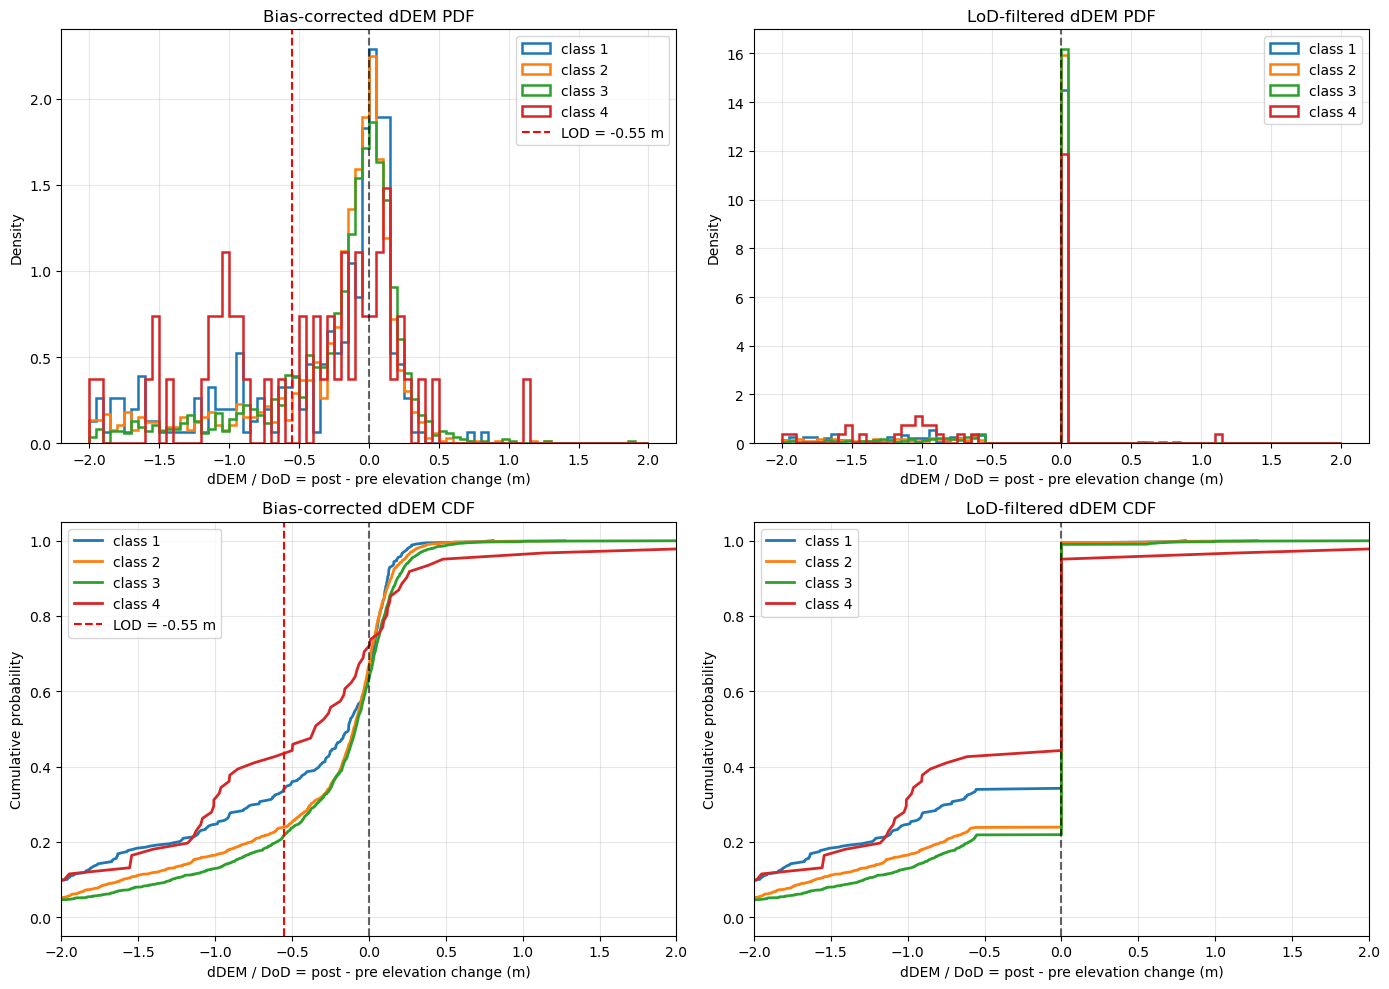

Bias-corrected dDEM stats


,class,n_pixels,DoD_min,DoD_p05,DoD_median,DoD_mean,DoD_p95,DoD_max
0,class 1,339,-4.147217,-2.361603,-0.131836,-0.555872,0.181946,0.806396
1,class 2,1377,-3.808838,-1.998438,-0.099304,-0.389703,0.230334,1.272644
2,class 3,1799,-3.706421,-1.910254,-0.086243,-0.322274,0.274365,2.336121
3,class 4,61,-3.176392,-2.359863,-0.345459,-0.530882,0.481140,3.120239


LoD-filtered dDEM stats


,class,n_pixels,DoD_LoD_min,DoD_LoD_p05,DoD_LoD_median,DoD_LoD_mean,DoD_LoD_p95,DoD_LoD_max
0,class 1,339,-4.147217,-2.361603,0.0,-0.530682,0.0,0.806396
1,class 2,1377,-3.808838,-1.998438,0.0,-0.351682,0.0,1.272644
2,class 3,1799,-3.706421,-1.910254,0.0,-0.291779,0.0,2.336121
3,class 4,61,-3.176392,-2.359863,0.0,-0.510428,0.0,3.120239


In [3]:
dod, dod_profile, dod_transform, dod_crs = read_raster(DOD_PATH)

# Make LoD-filtered dDEM.
# If sigma raster exists, LoD95 = 1.96 * sigma. Otherwise use fixed +/- abs(LOD).
dod_lod = dod.copy()

if SIGMA_PATH is not None and Path(SIGMA_PATH).exists():
    sigma, _, _, _ = read_raster(SIGMA_PATH)
    lod95 = 1.96 * sigma
    dod_lod[np.abs(dod_lod) < lod95] = 0
    print('Using pixel-wise LoD from sigma raster')
else:
    dod_lod[np.abs(dod_lod) < abs(LOD)] = 0
    print('Using fixed LoD: +/-', abs(LOD), 'm')

dod_groups = values_by_polygon_class(dod, dod_transform, dod_crs, MANUAL_CLASS_SHP, MANUAL_CLASS_FIELD)
dod_lod_groups = values_by_polygon_class(dod_lod, dod_transform, dod_crs, MANUAL_CLASS_SHP, MANUAL_CLASS_FIELD)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bias-corrected PDF
plt.sca(axes[0, 0])
for name, vals in dod_groups.items():
    plt.hist(vals[np.isfinite(vals)], bins=80, range=(-2, 2), density=True, histtype='step', linewidth=1.8, label=name)
plt.axvline(LOD, color='red', linestyle='--', label=f'LOD = {LOD} m')
plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.title('Bias-corrected dDEM PDF')
plt.xlabel('dDEM / DoD = post - pre elevation change (m)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

# LoD-filtered PDF
plt.sca(axes[0, 1])
for name, vals in dod_lod_groups.items():
    plt.hist(vals[np.isfinite(vals)], bins=80, range=(-2, 2), density=True, histtype='step', linewidth=1.8, label=name)
plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.title('LoD-filtered dDEM PDF')
plt.xlabel('dDEM / DoD = post - pre elevation change (m)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

# Bias-corrected CDF
plt.sca(axes[1, 0])
for name, vals in dod_groups.items():
    x, y = cdf_xy(vals)
    plt.plot(x, y, linewidth=2, label=name)
plt.axvline(LOD, color='red', linestyle='--', label=f'LOD = {LOD} m')
plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.xlim(-2, 2)
plt.title('Bias-corrected dDEM CDF')
plt.xlabel('dDEM / DoD = post - pre elevation change (m)')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(True, alpha=0.3)

# LoD-filtered CDF
plt.sca(axes[1, 1])
for name, vals in dod_lod_groups.items():
    x, y = cdf_xy(vals)
    plt.plot(x, y, linewidth=2, label=name)
plt.axvline(0, color='black', linestyle='--', alpha=0.6)
plt.xlim(-2, 2)
plt.title('LoD-filtered dDEM CDF')
plt.xlabel('dDEM / DoD = post - pre elevation change (m)')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Bias-corrected dDEM stats')
display(stats_table(dod_groups, 'DoD'))

print('LoD-filtered dDEM stats')
display(stats_table(dod_lod_groups, 'DoD_LoD'))

## 4. DeltaG by Our Manual Classes

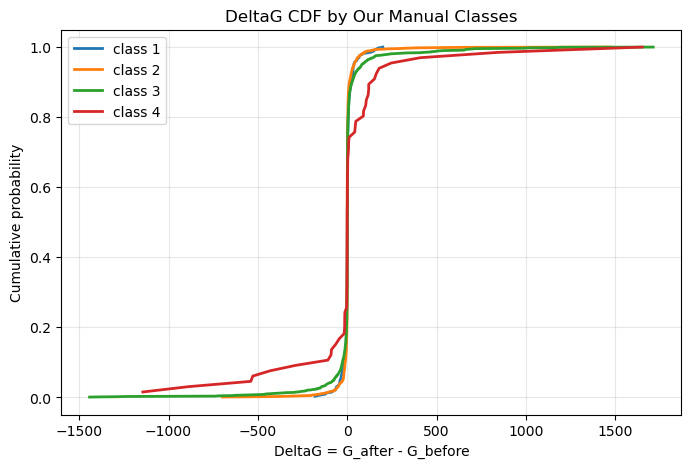

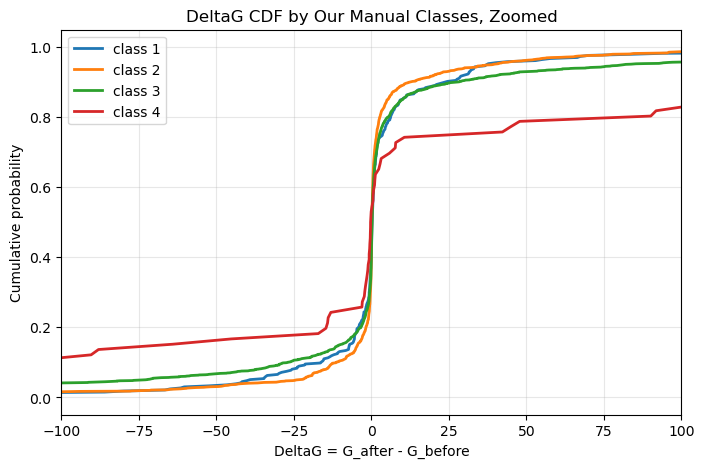

,class,n_pixels,DeltaG_min,DeltaG_p05,DeltaG_median,DeltaG_mean,DeltaG_p95,DeltaG_max
0,class 1,337,-180.231934,-35.552405,0.257396,1.861161,37.200639,199.254150
1,class 2,1368,-697.549194,-22.826078,0.116161,1.912454,39.146148,1475.515381
2,class 3,1803,-1441.879639,-72.231545,0.154886,3.113990,81.633945,1712.619507
3,class 4,66,-1143.777588,-503.906967,-0.219366,3.993062,229.500816,1651.518799


In [4]:
deltaG, delta_profile, delta_transform, delta_crs = read_raster(DELTAG_PATH)

# Keep class 4 here because it is the high/channelized class.
manual_delta_groups = values_by_polygon_class(deltaG, delta_transform, delta_crs, MANUAL_CLASS_SHP, MANUAL_CLASS_FIELD)

plot_cdf(
    manual_delta_groups,
    title='DeltaG CDF by Our Manual Classes',
    xlabel='DeltaG = G_after - G_before',
    xlim=None,
    logx=False,
)

plot_cdf(
    manual_delta_groups,
    title='DeltaG CDF by Our Manual Classes, Zoomed',
    xlabel='DeltaG = G_after - G_before',
    xlim=(-100, 100),
    logx=False,
)

display(stats_table(manual_delta_groups, 'DeltaG'))

## 5. DeltaG by Dunne Rill Classes

0% vegetation 11 shapefiles
0-25% bedrock/armor 11 shapefiles
25-50% rilled 11 shapefiles
50-75% rilled 6 shapefiles
75-100% rilled 11 shapefiles


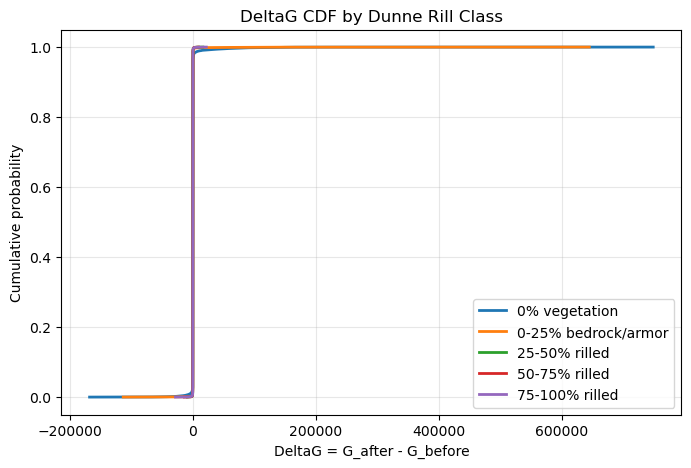

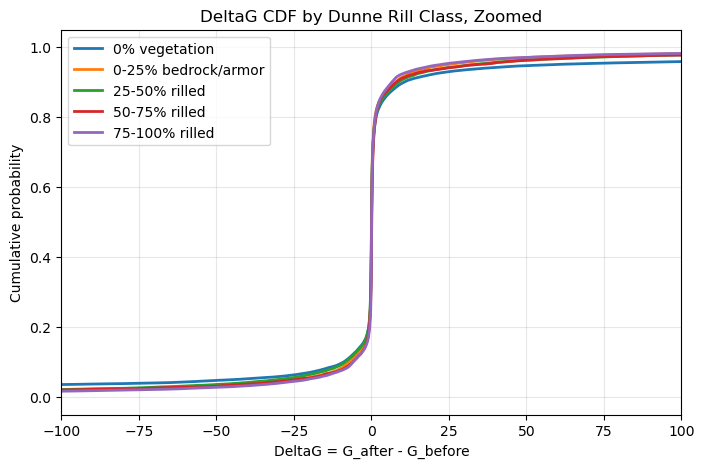

,class,n_pixels,DeltaG_min,DeltaG_p05,DeltaG_median,DeltaG_mean,DeltaG_p95,DeltaG_max
0,0% vegetation,41552,-167839.531250,-44.226712,0.022187,491.106256,58.874851,748556.687500
1,0-25% bedrock/armor,21287,-113166.453125,-23.893268,0.026484,158.832516,24.647250,644619.250000
2,25-50% rilled,31573,-8724.732422,-30.230890,0.045170,1.338096,33.020403,16304.521484
3,50-75% rilled,7736,-13688.143555,-24.314218,0.083408,2.650902,33.623872,9153.679688
4,75-100% rilled,47283,-28185.826172,-20.825484,0.062934,-0.794903,22.235517,21909.949219


In [5]:
def dunne_shapefiles_by_rill_class(root):
    root = Path(root)
    groups = {
        '0% vegetation': [],
        '0-25% bedrock/armor': [],
        '25-50% rilled': [],
        '50-75% rilled': [],
        '75-100% rilled': [],
    }

    for shp in root.rglob('*.shp'):
        name = shp.name.lower()
        folder = shp.parent.name.lower()

        # Skip watershed boundaries, geology contacts, and point/field folders.
        if folder in ['watershed_boundaries', 'geology_contacts', 'kean_data', 'historic_geomac_perimeters_2018-shp']:
            continue

        if 'veg' in name:
            groups['0% vegetation'].append(shp)
        elif 'bedrock' in name:
            groups['0-25% bedrock/armor'].append(shp)
        elif '25_rills' in name:
            groups['25-50% rilled'].append(shp)
        elif '50_rills' in name:
            groups['50-75% rilled'].append(shp)
        elif 'rills' in name:
            groups['75-100% rilled'].append(shp)

    return groups


def values_by_shapefile_groups(raster, transform, raster_crs, shp_groups, positive_only=False):
    out = {}
    for group_name, paths in shp_groups.items():
        geoms = []
        for path in paths:
            try:
                gdf = gpd.read_file(path).to_crs(raster_crs)
                geoms.extend(list(gdf.geometry))
            except Exception as e:
                print('skipped:', path, e)

        if len(geoms) == 0:
            out[group_name] = np.array([])
            continue

        mask = geometry_mask(geoms, out_shape=raster.shape, transform=transform, invert=True)
        vals = raster[mask & np.isfinite(raster)]
        if positive_only:
            vals = vals[vals > 0]
        out[group_name] = vals
    return out


dunne_shps = dunne_shapefiles_by_rill_class(DUNNE_ROOT)
for name, paths in dunne_shps.items():
    print(name, len(paths), 'shapefiles')

dunne_delta_groups = values_by_shapefile_groups(deltaG, delta_transform, delta_crs, dunne_shps)

plot_cdf(
    dunne_delta_groups,
    title='DeltaG CDF by Dunne Rill Class',
    xlabel='DeltaG = G_after - G_before',
    xlim=None,
    logx=False,
)

plot_cdf(
    dunne_delta_groups,
    title='DeltaG CDF by Dunne Rill Class, Zoomed',
    xlabel='DeltaG = G_after - G_before',
    xlim=(-100, 100),
    logx=False,
)

display(stats_table(dunne_delta_groups, 'DeltaG'))

## 6. Optional: G CDF by Our Manual Classes

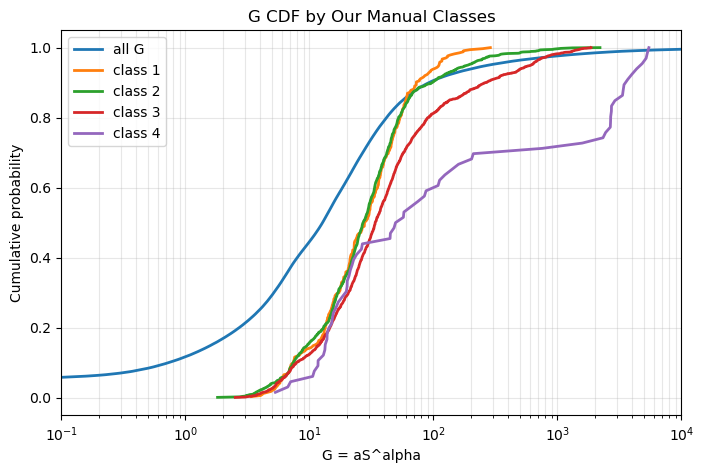

,class,n_pixels,G_min,G_p05,G_median,G_mean,G_p95,G_max
0,class 1,337,3.406621,6.042183,27.850597,37.823953,110.896991,287.901337
1,class 2,1368,1.817256,5.755841,27.134418,54.658538,189.778946,2204.322998
2,class 3,1803,2.524436,5.968795,33.940620,109.659159,612.829614,1869.972412
3,class 4,66,5.316273,10.709563,53.382351,1041.027475,4712.984375,5465.689941


In [6]:
if G_PATH is None:
    print('No G raster found. Set G_PATH manually in the first cell.')
else:
    G, G_profile, G_transform, G_crs = read_raster(G_PATH)
    manual_G_groups = values_by_polygon_class(G, G_transform, G_crs, MANUAL_CLASS_SHP, MANUAL_CLASS_FIELD, positive_only=True)

    all_G = G[np.isfinite(G) & (G > 0)]
    groups_with_all = {'all G': all_G}
    groups_with_all.update(manual_G_groups)

    plot_cdf(
        groups_with_all,
        title='G CDF by Our Manual Classes',
        xlabel='G = aS^alpha',
        xlim=(1e-1, 1e4),
        logx=True,
    )

    display(stats_table(manual_G_groups, 'G'))

## 7. Optional: G CDF by Dunne Rill Classes

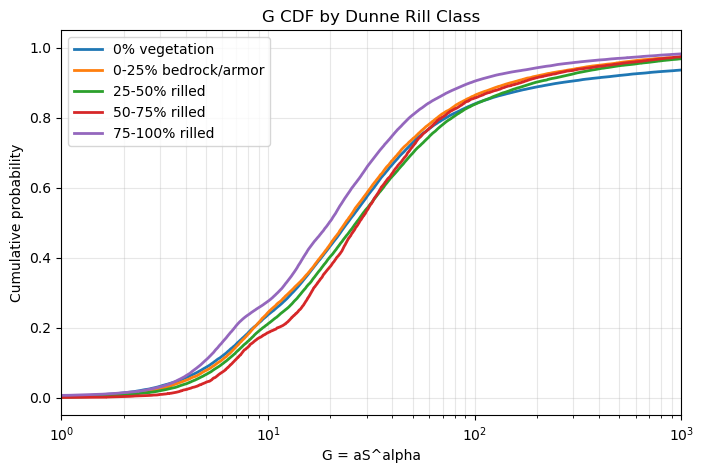

,class,n_pixels,G_min,G_p05,G_median,G_mean,G_p95,G_max
0,0% vegetation,41552,3.559285e-16,3.740465,24.281099,891.963478,2016.587134,220091.453125
1,0-25% bedrock/armor,21292,3.559285e-16,4.025178,23.687247,324.851966,405.371986,533555.750000
2,25-50% rilled,31577,4.395694e-14,4.425731,26.709364,147.469537,529.132300,70834.656250
3,50-75% rilled,7736,8.738437e-01,5.317449,27.573349,128.506429,449.781403,10638.375000
4,75-100% rilled,47280,3.559285e-16,3.669144,19.766763,105.814598,243.075584,31821.423828


In [7]:
if G_PATH is None:
    print('No G raster found. Set G_PATH manually in the first cell.')
else:
    dunne_G_groups = values_by_shapefile_groups(G, G_transform, G_crs, dunne_shps, positive_only=True)

    plot_cdf(
        dunne_G_groups,
        title='G CDF by Dunne Rill Class',
        xlabel='G = aS^alpha',
        xlim=(1, 1e3),
        logx=True,
    )

    display(stats_table(dunne_G_groups, 'G'))

polygons found:
  partB.shp
  partC.shp
  partD.shp


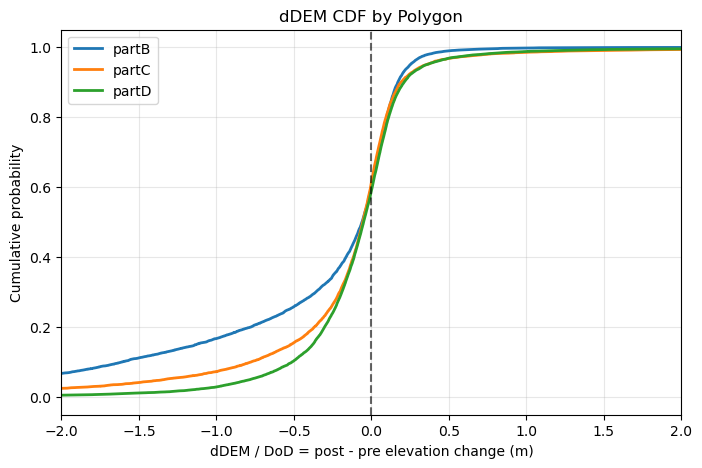

,polygon,n_pixels,DoD_min,DoD_p05,DoD_median,DoD_mean,DoD_p95,DoD_max
0,partB,9519,-12.459900,-2.268701,-0.061401,-0.424322,0.249023,4.129272
1,partC,8023,-12.337463,-1.342682,-0.056396,-0.184266,0.353247,11.825012
2,partD,14955,-7.061432,-0.786810,-0.050903,-0.093732,0.353964,14.159576


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import matplotlib.pyplot as plt

# -----------------------
# paths
# -----------------------
DOD_PATH = Path("/mnt/c/Users/amehedi/Downloads/Thomas_xDEM/xdem_stable_filter_comparison10/full_overlap/no_stable_mask_elev_gt_2m/best_corrected_products/final_DoD_post_minus_pre.tif")
# DOD_PATH = Path('/mnt/c/Users/amehedi/Downloads/final_DoD_post_minus_pre.tif')


POLYGON_DIR = Path("/mnt/c/Users/amehedi/Downloads")
POLYGON_FILES = sorted(POLYGON_DIR.glob("part*.shp"))

# LOD = -0.55

print("polygons found:")
for p in POLYGON_FILES:
    print(" ", p.name)

# -----------------------
# read dDEM
# -----------------------
with rasterio.open(DOD_PATH) as src:
    dod = src.read(1).astype("float64")
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

if nodata is not None:
    dod[dod == nodata] = np.nan

# -----------------------
# plot CDFs
# -----------------------
rows = []

plt.figure(figsize=(8, 5))

for shp in POLYGON_FILES:
    name = shp.stem

    gdf = gpd.read_file(shp)

    # if CRS is missing, assume EPSG:4326
    if gdf.crs is None:
        print(name, "has no CRS; assuming EPSG:4326")
        gdf = gdf.set_crs("EPSG:4326")

    gdf = gdf.to_crs(crs)

    mask = geometry_mask(
        gdf.geometry,
        out_shape=dod.shape,
        transform=transform,
        invert=True
    )

    values = dod[mask & np.isfinite(dod)]

    if len(values) == 0:
        print("No overlapping dDEM pixels for:", name)
        continue

    values_sorted = np.sort(values)
    cdf = np.arange(1, len(values_sorted) + 1) / len(values_sorted)

    plt.plot(values_sorted, cdf, linewidth=2, label=name)

    rows.append({
        "polygon": name,
        "n_pixels": len(values),
        "DoD_min": np.min(values),
        "DoD_p05": np.percentile(values, 5),
        "DoD_median": np.median(values),
        "DoD_mean": np.mean(values),
        "DoD_p95": np.percentile(values, 95),
        "DoD_max": np.max(values),
    })

plt.axvline(0, color="black", linestyle="--", alpha=0.6)
# plt.axvline(LOD, color="red", linestyle="--", label=f"LOD = {LOD} m")
plt.xlim(-2, 2)
plt.xlabel("dDEM / DoD = post - pre elevation change (m)")
plt.ylabel("Cumulative probability")
plt.title("dDEM CDF by Polygon")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

stats = pd.DataFrame(rows)
display(stats)

In [9]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from rasterio.transform import Affine

# -----------------------
# inputs
# -----------------------
DDEM_1M = Path("/mnt/c/Users/amehedi/Downloads/final_DoD_post_minus_pre.tif")
SIGMA_1M = Path("/mnt/c/Users/amehedi/Downloads/final_uncertainty_sigma_dh (1).tif")

OUT_DIR = Path("/mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM")
OUT_DIR.mkdir(exist_ok=True)

OUT_DDEM_10M = OUT_DIR / "dDEM_1m_upscaled_to_10m_median.tif"
OUT_SIGMA_10M = OUT_DIR / "sigma_dh_1m_upscaled_to_10m_rms.tif"
OUT_LOD95_10M = OUT_DIR / "LoD95_10m_from_sigma.tif"
OUT_DDEM_LOD = OUT_DIR / "dDEM_10m_LoD95_filtered.tif"

TARGET_RES = 10.0
NODATA = -9999.0

# -----------------------
# read 1 m dDEM
# -----------------------
with rasterio.open(DDEM_1M) as src:
    ddem = src.read(1).astype("float32")
    profile = src.profile.copy()
    src_transform = src.transform
    src_crs = src.crs
    bounds = src.bounds
    src_nodata = src.nodata

if src_nodata is not None:
    ddem[ddem == src_nodata] = np.nan

# -----------------------
# create 10 m grid
# -----------------------
left, bottom, right, top = bounds

width_10m = int(np.ceil((right - left) / TARGET_RES))
height_10m = int(np.ceil((top - bottom) / TARGET_RES))

transform_10m = Affine(TARGET_RES, 0, left, 0, -TARGET_RES, top)

profile_10m = profile.copy()
profile_10m.update({
    "height": height_10m,
    "width": width_10m,
    "transform": transform_10m,
    "dtype": "float32",
    "nodata": NODATA,
    "compress": "lzw"
})

# -----------------------
# 1) upscale dDEM to 10 m
# median preferred for source-zone evidence
# -----------------------
ddem_src = np.where(np.isfinite(ddem), ddem, NODATA).astype("float32")
ddem_10m = np.full((height_10m, width_10m), NODATA, dtype="float32")

try:
    ddem_resampling = Resampling.med
except AttributeError:
    print("Median resampling not available; using average.")
    ddem_resampling = Resampling.average

reproject(
    source=ddem_src,
    destination=ddem_10m,
    src_transform=src_transform,
    src_crs=src_crs,
    src_nodata=NODATA,
    dst_transform=transform_10m,
    dst_crs=src_crs,
    dst_nodata=NODATA,
    resampling=ddem_resampling,
)

ddem_10m = np.where(ddem_10m == NODATA, np.nan, ddem_10m)

# -----------------------
# 2) upscale sigma uncertainty to 10 m using RMS
# sigma_10m = sqrt(mean(sigma_1m^2))
# -----------------------
with rasterio.open(SIGMA_1M) as src:
    sigma = src.read(1).astype("float32")
    sigma_nodata = src.nodata

if sigma_nodata is not None:
    sigma[sigma == sigma_nodata] = np.nan

sigma2 = sigma ** 2
sigma2_src = np.where(np.isfinite(sigma2), sigma2, NODATA).astype("float32")
sigma2_10m = np.full((height_10m, width_10m), NODATA, dtype="float32")

reproject(
    source=sigma2_src,
    destination=sigma2_10m,
    src_transform=src_transform,
    src_crs=src_crs,
    src_nodata=NODATA,
    dst_transform=transform_10m,
    dst_crs=src_crs,
    dst_nodata=NODATA,
    resampling=Resampling.average,
)

sigma2_10m = np.where(sigma2_10m == NODATA, np.nan, sigma2_10m)
sigma_10m = np.sqrt(sigma2_10m)

# -----------------------
# 3) LoD95 and filtered dDEM
# -----------------------
LoD95_10m = 1.96 * sigma_10m

ddem_10m_lod = ddem_10m.copy()
not_significant = np.isfinite(ddem_10m_lod) & np.isfinite(LoD95_10m) & (np.abs(ddem_10m_lod) < LoD95_10m)
ddem_10m_lod[not_significant] = 0

# -----------------------
# save rasters
# -----------------------
def save_raster(path, arr):
    arr_out = np.where(np.isfinite(arr), arr, NODATA).astype("float32")
    with rasterio.open(path, "w", **profile_10m) as dst:
        dst.write(arr_out, 1)
    print("saved:", path)

save_raster(OUT_DDEM_10M, ddem_10m)
save_raster(OUT_SIGMA_10M, sigma_10m)
save_raster(OUT_LOD95_10M, LoD95_10m)
save_raster(OUT_DDEM_LOD, ddem_10m_lod)

print("dDEM 10m min/mean/max:", np.nanmin(ddem_10m), np.nanmean(ddem_10m), np.nanmax(ddem_10m))
print("LoD95 10m min/mean/max:", np.nanmin(LoD95_10m), np.nanmean(LoD95_10m), np.nanmax(LoD95_10m))
print("LoD-filtered dDEM min/mean/max:", np.nanmin(ddem_10m_lod), np.nanmean(ddem_10m_lod), np.nanmax(ddem_10m_lod))

saved: /mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/dDEM_1m_upscaled_to_10m_median.tif
saved: /mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/sigma_dh_1m_upscaled_to_10m_rms.tif
saved: /mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/LoD95_10m_from_sigma.tif
saved: /mnt/c/Users/amehedi/Downloads/LoD_filtered_dDEM/dDEM_10m_LoD95_filtered.tif
dDEM 10m min/mean/max: -27.605225 -0.06150435 31.549377
LoD95 10m min/mean/max: 0.07894528 0.306844 3.4908931
LoD-filtered dDEM min/mean/max: -27.605225 -0.04009575 31.549377


In [1]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from rasterio.transform import Affine

# -----------------------
# inputs
# -----------------------
DDEM_1M = Path("/mnt/c/Users/amehedi/Downloads/final_DoD_post_minus_pre.tif")
SIGMA_1M = Path("/mnt/c/Users/amehedi/Downloads/final_uncertainty_sigma_dh (1).tif")

OUT_DIR = Path("/mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m")
OUT_DIR.mkdir(exist_ok=True)

TARGET_RES = 10.0
NODATA = -9999.0

# -----------------------
# read 1 m dDEM
# -----------------------
with rasterio.open(DDEM_1M) as src:
    ddem = src.read(1).astype("float32")
    profile = src.profile.copy()
    src_transform = src.transform
    src_crs = src.crs
    bounds = src.bounds
    src_nodata = src.nodata

if src_nodata is not None:
    ddem[ddem == src_nodata] = np.nan

# -----------------------
# read 1 m uncertainty
# -----------------------
with rasterio.open(SIGMA_1M) as src:
    sigma = src.read(1).astype("float32")
    sigma_nodata = src.nodata

if sigma_nodata is not None:
    sigma[sigma == sigma_nodata] = np.nan

# -----------------------
# create 10 m grid
# -----------------------
left, bottom, right, top = bounds

width_10m = int(np.ceil((right - left) / TARGET_RES))
height_10m = int(np.ceil((top - bottom) / TARGET_RES))

transform_10m = Affine(TARGET_RES, 0, left, 0, -TARGET_RES, top)

profile_10m = profile.copy()
profile_10m.update({
    "height": height_10m,
    "width": width_10m,
    "transform": transform_10m,
    "dtype": "float32",
    "nodata": NODATA,
    "compress": "lzw"
})

# -----------------------
# helper: aggregate to 10 m
# -----------------------
def aggregate_to_10m(arr, method, out_name):
    src_arr = np.where(np.isfinite(arr), arr, NODATA).astype("float32")
    dst_arr = np.full((height_10m, width_10m), NODATA, dtype="float32")

    reproject(
        source=src_arr,
        destination=dst_arr,
        src_transform=src_transform,
        src_crs=src_crs,
        src_nodata=NODATA,
        dst_transform=transform_10m,
        dst_crs=src_crs,
        dst_nodata=NODATA,
        resampling=method,
    )

    dst_arr = np.where(dst_arr == NODATA, np.nan, dst_arr)

    out_path = OUT_DIR / out_name
    save_arr = np.where(np.isfinite(dst_arr), dst_arr, NODATA).astype("float32")

    with rasterio.open(out_path, "w", **profile_10m) as dst:
        dst.write(save_arr, 1)

    print("saved:", out_path)
    return dst_arr

# -----------------------
# pixel-wise LoD at 1 m
# -----------------------
LoD95_1m = 1.96 * sigma

valid = np.isfinite(ddem) & np.isfinite(LoD95_1m)

sig_erosion_1m = np.full(ddem.shape, np.nan, dtype="float32")
sig_erosion_1m[valid] = (ddem[valid] < -LoD95_1m[valid]).astype("float32")

sig_deposition_1m = np.full(ddem.shape, np.nan, dtype="float32")
sig_deposition_1m[valid] = (ddem[valid] > LoD95_1m[valid]).astype("float32")

valid_1m = np.full(ddem.shape, np.nan, dtype="float32")
valid_1m[valid] = 1.0

# -----------------------
# 10 m evidence rasters
# -----------------------
frac_sig_erosion_10m = aggregate_to_10m(
    sig_erosion_1m,
    Resampling.average,
    "frac_sig_erosion_10m.tif"
)

frac_sig_deposition_10m = aggregate_to_10m(
    sig_deposition_1m,
    Resampling.average,
    "frac_sig_deposition_10m.tif"
)

valid_fraction_10m = aggregate_to_10m(
    valid_1m,
    Resampling.average,
    "valid_fraction_10m.tif"
)

mean_DoD_10m = aggregate_to_10m(
    ddem,
    Resampling.average,
    "mean_DoD_10m.tif"
)

try:
    median_method = Resampling.med
except AttributeError:
    print("Median resampling not available; using average instead.")
    median_method = Resampling.average

median_DoD_10m = aggregate_to_10m(
    ddem,
    median_method,
    "median_DoD_10m.tif"
)

# std = sqrt(mean(x^2) - mean(x)^2)
mean_DoD2_10m = aggregate_to_10m(
    ddem ** 2,
    Resampling.average,
    "mean_DoD_squared_10m.tif"
)

std_DoD_10m = np.sqrt(np.maximum(mean_DoD2_10m - mean_DoD_10m**2, 0))

std_path = OUT_DIR / "std_DoD_10m.tif"
save_std = np.where(np.isfinite(std_DoD_10m), std_DoD_10m, NODATA).astype("float32")

with rasterio.open(std_path, "w", **profile_10m) as dst:
    dst.write(save_std, 1)

print("saved:", std_path)

print("Done.")
print("fraction erosion min/mean/max:", np.nanmin(frac_sig_erosion_10m), np.nanmean(frac_sig_erosion_10m), np.nanmax(frac_sig_erosion_10m))
print("fraction deposition min/mean/max:", np.nanmin(frac_sig_deposition_10m), np.nanmean(frac_sig_deposition_10m), np.nanmax(frac_sig_deposition_10m))
print("mean DoD min/mean/max:", np.nanmin(mean_DoD_10m), np.nanmean(mean_DoD_10m), np.nanmax(mean_DoD_10m))
print("std DoD min/mean/max:", np.nanmin(std_DoD_10m), np.nanmean(std_DoD_10m), np.nanmax(std_DoD_10m))

saved: /mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/frac_sig_erosion_10m.tif
saved: /mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/frac_sig_deposition_10m.tif
saved: /mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/valid_fraction_10m.tif
saved: /mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/mean_DoD_10m.tif
saved: /mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/median_DoD_10m.tif
saved: /mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/mean_DoD_squared_10m.tif
saved: /mnt/c/Users/amehedi/Downloads/dDEM_10m_evidence_from_1m/std_DoD_10m.tif
Done.
fraction erosion min/mean/max: 0.0 0.13803405 1.0
fraction deposition min/mean/max: 0.0 0.05759728 1.0
mean DoD min/mean/max: -27.3098 -0.08133009 31.516594
std DoD min/mean/max: 0.0 0.20077297 7.6213484


In [2]:
from pathlib import Path
import numpy as np
import rasterio
import whitebox

# -----------------------
# Paths
# -----------------------
PRE_DEM = Path("/mnt/c/Users/amehedi/Downloads/final_post_corrected.tif")
OUT = Path("/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_post")
OUT.mkdir(parents=True, exist_ok=True)

FILLED = OUT / "post_filled_1m.tif"
SLOPE_DEG = OUT / "S_post_degrees_1m.tif"
FLOW_ACC = OUT / "flow_accum_post_cells_1m.tif"

S_OUT = OUT / "S_post_1m.tif"
A_OUT = OUT / "a_post_1m.tif"
G_OUT = OUT / "G_post_1m.tif"

ALPHA = 1.167

# -----------------------
# Whitebox terrain routing
# -----------------------
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

# Fill depressions
wbt.fill_depressions(
    dem=str(PRE_DEM),
    output=str(FILLED),
)

# Slope in degrees
wbt.slope(
    dem=str(FILLED),
    output=str(SLOPE_DEG),
    units="degrees",
)

# D8 flow accumulation in number of cells
wbt.d8_flow_accumulation(
    i=str(FILLED),
    output=str(FLOW_ACC),
    out_type="cells",
)

# -----------------------
# Convert to S, a, G
# -----------------------
with rasterio.open(PRE_DEM) as src:
    profile = src.profile.copy()
    cell_size = abs(src.transform.a)

with rasterio.open(SLOPE_DEG) as src:
    slope_deg = src.read(1).astype("float64")
    slope_nodata = src.nodata

with rasterio.open(FLOW_ACC) as src:
    flow_cells = src.read(1).astype("float64")
    flow_nodata = src.nodata

if slope_nodata is not None:
    slope_deg[slope_deg == slope_nodata] = np.nan

if flow_nodata is not None:
    flow_cells[flow_cells == flow_nodata] = np.nan

# slope m/m
S = np.tan(np.deg2rad(slope_deg))

# drainage area = contributing cell count * cell area
drainage_area = flow_cells * cell_size * cell_size

# specific catchment area a = drainage area / contour width
a = drainage_area / cell_size

# topographic driving index
G = a * (S ** ALPHA)

# -----------------------
# Save outputs
# -----------------------
profile.update(dtype="float32", nodata=-9999.0, compress="deflate")

def save(path, arr):
    arr = arr.astype("float32")
    arr_out = np.where(np.isfinite(arr), arr, -9999.0)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr_out, 1)

save(S_OUT, S)
save(A_OUT, a)
save(G_OUT, G)

print("saved to:", OUT)
print("S min/mean/max:", np.nanmin(S), np.nanmean(S), np.nanmax(S))
print("a min/mean/max:", np.nanmin(a), np.nanmean(a), np.nanmax(a))
print("G min/mean/max:", np.nanmin(G), np.nanmean(G), np.nanmax(G))

saved to: /mnt/c/Users/amehedi/Downloads/G_1m_whitebox_post
S min/mean/max: 0.0 0.45113941225390897 8.43981041762895
a min/mean/max: 1.0 4193.83080684634 17377996.0
G min/mean/max: 0.0 305.58681294436633 13161087.62460333


In [3]:
from pathlib import Path
import numpy as np
import rasterio

PRE_G  = Path("/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre/G_pre_1m.tif")
POST_G = Path("/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_post/G_post_1m.tif")

OUT = Path("/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta")
OUT.mkdir(parents=True, exist_ok=True)

DELTA_G_OUT = OUT / "DeltaG_1m.tif"
DELTA_G_PERCENT_OUT = OUT / "DeltaG_percent_1m.tif"

# -----------------------
# Read G rasters
# -----------------------
with rasterio.open(PRE_G) as src:
    G_pre = src.read(1).astype("float64")
    profile = src.profile.copy()
    nodata = src.nodata

with rasterio.open(POST_G) as src:
    G_post = src.read(1).astype("float64")
    post_nodata = src.nodata

if nodata is not None:
    G_pre[G_pre == nodata] = np.nan

if post_nodata is not None:
    G_post[G_post == post_nodata] = np.nan

# -----------------------
# DeltaG = post - pre
# -----------------------
DeltaG = G_post - G_pre

DeltaG_percent = np.full(G_pre.shape, np.nan, dtype="float32")
ok = np.isfinite(G_pre) & np.isfinite(G_post) & (G_pre != 0)
DeltaG_percent[ok] = 100 * DeltaG[ok] / G_pre[ok]

# -----------------------
# Save
# -----------------------
profile.update(dtype="float32", nodata=-9999.0, compress="deflate")

def save(path, arr):
    arr = arr.astype("float32")
    arr_out = np.where(np.isfinite(arr), arr, -9999.0)
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(arr_out, 1)

save(DELTA_G_OUT, DeltaG)
save(DELTA_G_PERCENT_OUT, DeltaG_percent)

print("saved:", DELTA_G_OUT)
print("saved:", DELTA_G_PERCENT_OUT)
print("DeltaG min/mean/max:", np.nanmin(DeltaG), np.nanmean(DeltaG), np.nanmax(DeltaG))

saved: /mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif
saved: /mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_percent_1m.tif
DeltaG min/mean/max: -23199888.971070766 -35.38357609576474 13161083.139230251


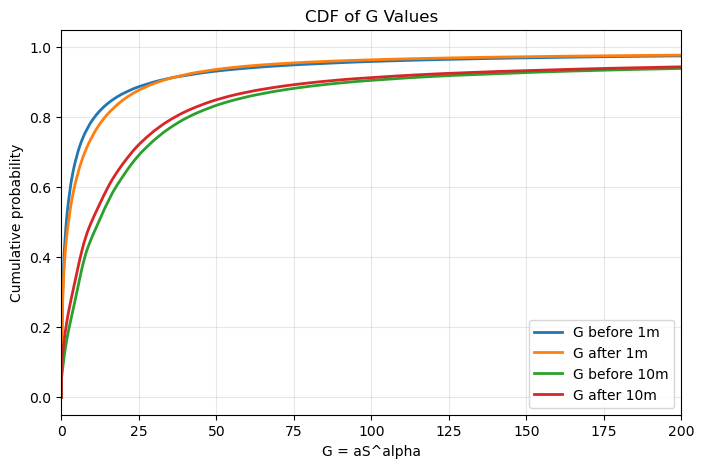

In [7]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# -----------------------
# Paths
# -----------------------
rasters = {
    "G before 1m": "/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre/G_pre_1m.tif",
    "G after 1m":  "/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_post/G_post_1m.tif",
    "DeltaG 1m":   "/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif",

    "G before 10m": "/mnt/c/Users/amehedi/Downloads/thomas/G_before.tif",
    "G after 10m":  "/mnt/c/Users/amehedi/Downloads/thomas/G_after.tif",
    "DeltaG 10m":   "/mnt/c/Users/amehedi/Downloads/thomas/DeltaG.tif",
}

# -----------------------
# Helper
# -----------------------
def read_values(path, positive_only=True):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        nodata = src.nodata

    if nodata is not None:
        arr[arr == nodata] = np.nan

    values = arr[np.isfinite(arr)]

    if positive_only:
        values = values[values > 0]

    return values

def plot_cdf(values, label):
    values = np.sort(values)
    cdf = np.arange(1, len(values) + 1) / len(values)
    plt.plot(values, cdf, linewidth=2, label=label)

# -----------------------
# G CDFs on log x-axis
# -----------------------
plt.figure(figsize=(8, 5))

for name in ["G before 1m", "G after 1m", "G before 10m", "G after 10m"]:
    vals = read_values(rasters[name], positive_only=True)
    plot_cdf(vals, name)

# plt.xscale("log")
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.xlim(0, 200)
plt.title("CDF of G Values")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

# -----------------------
# DeltaG CDFs, normal x-axis
# -----------------------
# plt.figure(figsize=(8, 5))

# for name in ["DeltaG 1m", "DeltaG 10m"]:
#     vals = read_values(rasters[name], positive_only=False)
#     plot_cdf(vals, name)

# plt.xlabel("DeltaG = G_after - G_before")
# plt.ylabel("Cumulative probability")
# plt.xlim(-100, 100)
# plt.title("CDF of DeltaG Values")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # -----------------------
# # Quick stats
# # -----------------------
# for name, path in rasters.items():
#     vals = read_values(path, positive_only=False)
#     print(name)
#     print("  n:", len(vals))
#     print("  min/median/mean/max:", np.nanmin(vals), np.nanmedian(vals), np.nanmean(vals), np.nanmax(vals))

In [9]:
from pathlib import Path
import numpy as np
import rasterio
from affine import Affine

# -----------------------
# Inputs
# -----------------------
DELTA_G_1M = Path("/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_delta/DeltaG_1m.tif")

OUT = Path("/mnt/c/Users/amehedi/Downloads/DeltaG_10m_blocks_from_1m")
OUT.mkdir(parents=True, exist_ok=True)

BLOCK = 10   # 10 pixels x 10 pixels = 10 m cell if input is 1 m

# -----------------------
# Read 1 m DeltaG
# -----------------------
with rasterio.open(DELTA_G_1M) as src:
    dG = src.read(1).astype("float32")
    profile = src.profile.copy()
    nodata = src.nodata
    transform = src.transform

if nodata is not None:
    dG[dG == nodata] = np.nan

# crop edges so array divides cleanly by 10
h, w = dG.shape
h_crop = (h // BLOCK) * BLOCK
w_crop = (w // BLOCK) * BLOCK
dG = dG[:h_crop, :w_crop]

# reshape into 10x10 blocks
blocks = dG.reshape(h_crop // BLOCK, BLOCK, w_crop // BLOCK, BLOCK)

# -----------------------
# Fraction positive DeltaG
# -----------------------
valid = np.isfinite(blocks)
positive = (blocks > 0) & valid

valid_count = valid.sum(axis=(1, 3))
positive_count = positive.sum(axis=(1, 3))

frac_positive = np.where(
    valid_count > 0,
    positive_count / valid_count,
    np.nan
).astype("float32")

# -----------------------
# Median and std DeltaG
# -----------------------
median_dG = np.nanmedian(blocks, axis=(1, 3)).astype("float32")
std_dG = np.nanstd(blocks, axis=(1, 3)).astype("float32")

# -----------------------
# Save 10 m rasters
# -----------------------
profile.update(
    height=frac_positive.shape[0],
    width=frac_positive.shape[1],
    transform=transform * Affine.scale(BLOCK, BLOCK),
    dtype="float32",
    nodata=-9999.0,
    compress="deflate"
)

def save(path, arr):
    out = np.where(np.isfinite(arr), arr, -9999.0).astype("float32")
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(out, 1)

save(OUT / "DeltaG_fraction_positive_10m_from_1m.tif", frac_positive)
save(OUT / "DeltaG_median_10m_from_1m.tif", median_dG)
save(OUT / "DeltaG_std_10m_from_1m.tif", std_dG)

print("saved to:", OUT)
print("fraction positive min/mean/max:", np.nanmin(frac_positive), np.nanmean(frac_positive), np.nanmax(frac_positive))
print("median DeltaG min/mean/max:", np.nanmin(median_dG), np.nanmean(median_dG), np.nanmax(median_dG))
print("std DeltaG min/mean/max:", np.nanmin(std_dG), np.nanmean(std_dG), np.nanmax(std_dG))

/tmp/ipykernel_85826/1545222081.py:48: RuntimeWarning: invalid value encountered in divide
  positive_count / valid_count,
/tmp/ipykernel_85826/1545222081.py:55: RuntimeWarning: All-NaN slice encountered
  median_dG = np.nanmedian(blocks, axis=(1, 3)).astype("float32")
/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


saved to: /mnt/c/Users/amehedi/Downloads/DeltaG_10m_blocks_from_1m
fraction positive min/mean/max: 0.0 0.53671664 1.0
median DeltaG min/mean/max: -408.03314 1.3583207 30518.492
std DeltaG min/mean/max: 0.0 1756.4336 3537255.8


In [1]:
import numpy as np
import rasterio
from rasterio.transform import Affine
from pathlib import Path

G_PRE_PATH = r"/mnt/c/Users/amehedi/Downloads/G_1m_whitebox_pre/G_pre_1m.tif"
OUT_DIR    = Path(r"/mnt/c/Users/amehedi/Downloads/source_zone_labels")
BLOCK      = 10

# Load
with rasterio.open(G_PRE_PATH) as src:
    g_pre = src.read(1).astype("float32")
    nodata = src.nodata
    PROF   = src.profile
    if nodata is not None:
        g_pre[g_pre == nodata] = np.nan

print(f"Loaded G_pre {g_pre.shape}")

# Pad
H, W  = g_pre.shape
pad_h = (BLOCK - H % BLOCK) % BLOCK
pad_w = (BLOCK - W % BLOCK) % BLOCK
gp    = np.pad(g_pre, ((0, pad_h), (0, pad_w)), constant_values=np.nan)

# Reshape → block max
H2, W2 = gp.shape
gb     = gp.reshape(H2 // BLOCK, BLOCK, W2 // BLOCK, BLOCK)
with np.errstate(all="ignore"):
    g_star = np.nanmax(gb, axis=(1, 3)).astype("float32")

print(f"G* shape: {g_star.shape}  max={np.nanmax(g_star):.2f}  mean={np.nanmean(g_star):.2f}")

# Write
t0  = PROF["transform"]
t10 = Affine(t0.a * BLOCK, t0.b, t0.c, t0.d, t0.e * BLOCK, t0.f)
out = np.where(np.isfinite(g_star), g_star, -9999.0).astype("float32")

with rasterio.open(OUT_DIR / "G_star_10m.tif", "w", driver="GTiff",
                   height=g_star.shape[0], width=g_star.shape[1],
                   count=1, dtype="float32", crs=PROF["crs"],
                   transform=t10, nodata=-9999.0, compress="lzw") as dst:
    dst.write(out, 1)

print(f"Written → G_star_10m.tif")


Loaded G_pre (10986, 7425)
G* shape: (1099, 743)  max=23199890.00  mean=8361.79
Written → G_star_10m.tif


/tmp/ipykernel_401252/3011752592.py:30: RuntimeWarning: All-NaN slice encountered
  g_star = np.nanmax(gb, axis=(1, 3)).astype("float32")
